# Strava Cycling Analysis
## 12 Years of Riding Data: Fitness, Performance & Training Patterns

An exploratory data science project analyzing personal cycling data from 2014–2026.
Covers fitness progression, training load modeling, and ride classification using
power meter and heart rate data.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style="darkgrid")


In [51]:
# Load the data
df = pd.read_csv("activities.csv")

# Filter to outdoor rides only
rides = df[df['Activity Type'] == 'Ride'].copy()

# Parse dates
rides['date'] = pd.to_datetime(rides['Activity Date'], format='%b %d, %Y, %I:%M:%S %p')

# Sort chronologically
rides = rides.sort_values('date').reset_index(drop=True)

print(f"Total outdoor rides: {len(rides)}")
print(f"Date range: {rides['date'].min().date()} to {rides['date'].max().date()}")


Total outdoor rides: 1344
Date range: 2014-11-09 to 2026-04-30


In [52]:
# Look at all 2026 activities before any filtering
df_2026 = df.copy()
df_2026['date'] = pd.to_datetime(df_2026['Activity Date'], format='%b %d, %Y, %I:%M:%S %p')
df_2026 = df_2026[df_2026['date'].dt.year == 2026]

print("=== All 2026 activity types ===")
print(df_2026['Activity Type'].value_counts())

print("\n=== 2026 activities by month ===")
df_2026['month'] = df_2026['date'].dt.month
print(df_2026.groupby(['month', 'Activity Type']).size().unstack(fill_value=0))

=== All 2026 activity types ===
Activity Type
Ride               61
Walk                6
Weight Training     2
Name: count, dtype: int64

=== 2026 activities by month ===
Activity Type  Ride  Walk  Weight Training
month                                     
1                18     0                2
2                13     1                0
3                18     0                0
4                12     5                0


In [53]:
rides.head()

,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,...,With Pet,Competition,Long Run,For a Cause,With Kid,Downhill Distance,Total Sets,Total Reps,Media,date
0,284209540,"Nov 9, 2014, 12:05:19 PM",Atlantic Highlands - Cycle - Cyclemeter,Ride,NaN,4188,26.62,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-11-09 12:05:19
1,226235356,"Dec 4, 2014, 6:44:44 PM","12/04/2014 Atlantic Highlands, New Jersey",Ride,NaN,1716,10.30,158.0,17.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-12-04 18:44:44
2,228920213,"Dec 13, 2014, 12:40:04 PM","12/13/2014 Atlantic Highlands, New Jersey",Ride,NaN,2103,10.19,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-12-13 12:40:04
3,292993987,"Apr 12, 2015, 7:23:41 PM",Atlantic Highlands - Cycle - Cyclemeter,Ride,NaN,4981,19.31,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-04-12 19:23:41
4,301938633,"Apr 12, 2015, 7:26:56 PM","04/12/2015 Atlantic Highlands, New Jersey",Ride,NaN,4805,19.67,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-04-12 19:26:56


In [54]:
# Convert units and extract key columns
rides['distance_miles'] = pd.to_numeric(rides['Distance.1'], errors='coerce') / 1609.34
rides['elevation_ft'] = pd.to_numeric(rides['Elevation Gain'], errors='coerce') * 3.28084
rides['moving_time_hrs'] = pd.to_numeric(rides['Moving Time'], errors='coerce') / 3600
rides['wap'] = pd.to_numeric(rides['Weighted Average Power'], errors='coerce')
rides['avg_hr'] = pd.to_numeric(rides['Average Heart Rate'], errors='coerce')
rides['calories'] = pd.to_numeric(rides['Calories'], errors='coerce')

# Extract date parts
rides['year'] = rides['date'].dt.year
rides['month'] = rides['date'].dt.month

print(rides[['date', 'distance_miles', 'elevation_ft', 'wap', 'avg_hr']].tail())

                    date  distance_miles  elevation_ft    wap  avg_hr
1339 2026-04-23 09:06:44       25.945543       0.00000  137.0   133.0
1340 2026-04-27 19:39:23       25.523072    1732.28352  183.0   146.0
1341 2026-04-28 17:33:12       47.127394    4225.72192  179.0   150.0
1342 2026-04-29 18:11:12       24.133931    1486.22052  146.0   130.0
1343 2026-04-30 13:23:16        6.667640     780.83992  100.0   116.0


In [55]:
# Compare outdoor vs virtual rides by year
all_rides = df[df['Activity Type'].isin(['Ride', 'Virtual Ride'])].copy()
all_rides['date'] = pd.to_datetime(all_rides['Activity Date'], format='%b %d, %Y, %I:%M:%S %p')
all_rides['year'] = all_rides['date'].dt.year

print(all_rides.groupby(['year', 'Activity Type']).size().unstack(fill_value=0))

Activity Type  Ride  Virtual Ride
year                             
2014              3             0
2015             79             9
2016            130             0
2017            130             0
2018             64            19
2019             26           156
2020             62           124
2021            122            41
2022            178            14
2023            177             0
2024            153             0
2025            159             6
2026             61             0


In [56]:
# Let's perform some data data checks

# key columns to be used throughout the analysis
key_cols = ['distance_miles', 'elevation_ft', 'moving_time_hrs', 'wap', 'avg_hr', 'calories']

# Check for nulls
print("=== Null Values ===")
print(rides[key_cols].isnull().sum())

# Check for zero values
print("\n=== Zero value counts ===")
print((rides[key_cols] == 0).sum())

# Coverage by year
print("\n=== Rides with power data by year ===")
print(rides.groupby('year')['wap'].apply(lambda x: x.notna().sum()))

=== Null Values ===
distance_miles       0
elevation_ft         0
moving_time_hrs      0
wap                192
avg_hr             146
calories             2
dtype: int64

=== Zero value counts ===
distance_miles       3
elevation_ft       550
moving_time_hrs      1
wap                  0
avg_hr               1
calories             6
dtype: int64

=== Rides with power data by year ===
year
2014      2
2015     25
2016     68
2017     90
2018     61
2019     22
2020     62
2021    119
2022    171
2023    172
2024    149
2025    151
2026     60
Name: wap, dtype: int64


In [57]:
# Flag indoor rides using zero elevation as the indicator
# Trainerroad syncs to Strava without elevation data
rides['is_indoor'] = rides['elevation_ft'] == 0

print("\n=== Indoor vs Outdoor Rides ===")
print(rides['is_indoor'].value_counts())

print("\n=== Indoor vs Outdoor Rides by Year ===")
print(rides.groupby(['year', 'is_indoor']).size().unstack(fill_value=0).rename(columns={False: 'Outdoor', True: 'Indoor'}))



=== Indoor vs Outdoor Rides ===
is_indoor
False    794
True     550
Name: count, dtype: int64

=== Indoor vs Outdoor Rides by Year ===
is_indoor  Outdoor  Indoor
year                      
2014             3       0
2015            58      21
2016            71      59
2017            78      52
2018            56       8
2019            26       0
2020            62       0
2021            97      25
2022            75     103
2023           100      77
2024            69      84
2025            83      76
2026            16      45


## Section 1: Annual Training Overview
How has riding volume, elevation, and power output changed across 12 years?

In [58]:
# Create a summary table by year showing - total rides, total miles, total elevation gain, average weighted power, average power

summary_by_year = rides.groupby('year').agg(
    total_rides=('date', 'count'),
    total_miles=('distance_miles', 'sum'),
    total_elevation_gain=('elevation_ft', 'sum'),
    avg_weighted_power=('wap', 'mean'),
    avg_hr=('avg_hr', 'mean')
).round(1)

print(summary_by_year)

      total_rides  total_miles  total_elevation_gain  avg_weighted_power  \
year                                                                       
2014            3         29.3                 405.2               107.0   
2015           79       1921.9               51643.7               116.8   
2016          130       2880.1               80183.7               118.6   
2017          130       3416.3               76744.8               152.4   
2018           64       2077.5               67136.2               173.9   
2019           26       1336.5               63662.7               170.9   
2020           62       2371.1               86345.1               188.5   
2021          122       3764.8              128008.2               175.9   
2022          178       5081.5              107424.5               169.5   
2023          177       5257.6              151901.9               166.4   
2024          153       4454.2              100039.4               159.6   
2025        

### Observations
- Volume peaked in 2022–2023, likely reflecting increased training time during WFH period
- Average weighted power rose steadily from 2014 to 2020 (107W → 189W), then gradually declined
- Power decline post-2020 may reflect higher endurance volume, inclusion of indoor recovery rides, and age-related factors
- 2024 volume was reduced by a mid-year wrist fracture (approximately 6 weeks lost)
- 2026 data is partial due to a clavicle fracture in late April

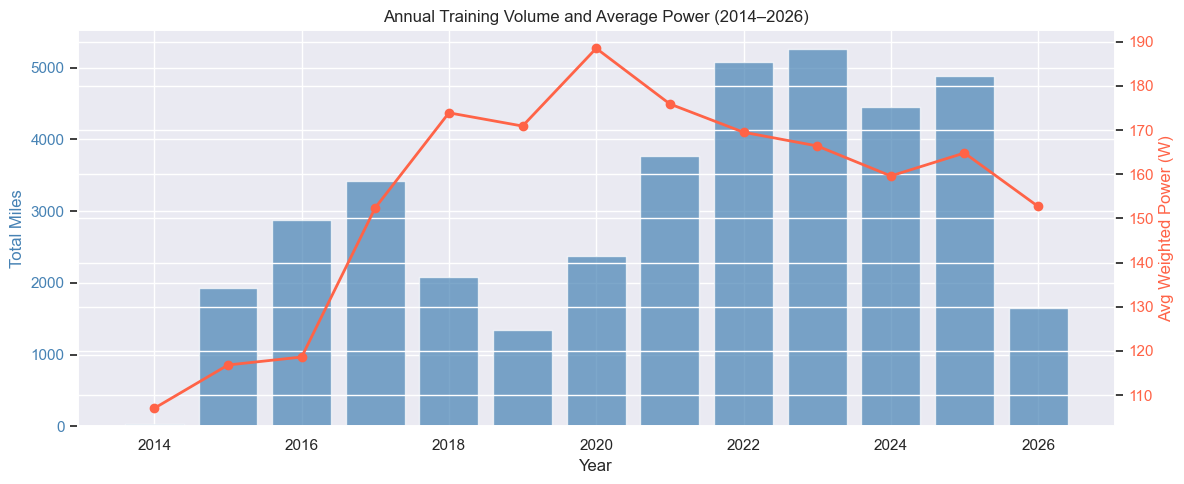

In [59]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar chart for total miles on left axis
ax1.bar(summary_by_year.index, summary_by_year['total_miles'], color='steelblue', alpha=0.7, label='Total Miles')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Miles', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart for average power on right axis
ax2 = ax1.twinx()
ax2.plot(summary_by_year.index, summary_by_year['avg_weighted_power'], color='tomato', marker='o', linewidth=2, label='Avg Power (W)')
ax2.set_ylabel('Avg Weighted Power (W)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title('Annual Training Volume and Average Power (2014–2026)')
fig.tight_layout()
plt.show()

In [60]:
# Power to HR ratio as an aerobic fitness proxy
# A rising ratio means more power per heartbeat = improved efficiency
phr = rides[(rides['wap'].notna()) & (rides['avg_hr'].notna())].copy()
phr['power_hr_ratio'] = phr['wap'] / phr['avg_hr']

phr_by_year = phr.groupby('year')['power_hr_ratio'].mean().round(3)
print(phr_by_year)

year
2014    0.848
2015    1.027
2016      inf
2017    1.175
2018    1.238
2019    1.232
2020    1.339
2021    1.210
2022    1.206
2023    1.182
2024    1.174
2025    1.182
2026    1.111
Name: power_hr_ratio, dtype: float64


### Observations
- Volume peaked in 2022–2023, likely reflecting increased training time during WFH period
- Average weighted power rose steadily from 2014 to 2020 (107W → 189W), then gradually declined
- Power:HR ratio has declined steadily since 2020, consistent with increased endurance 
  volume at lower intensity rather than high-intensity structured work
- 2024 volume was reduced by a mid-year wrist fracture (approximately 6 weeks lost)
- 2026 data is partial and ongoing

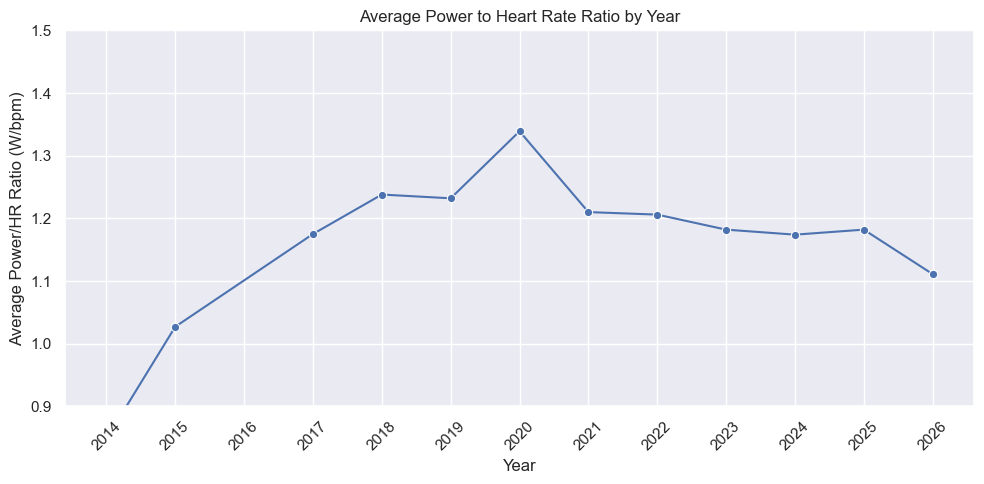

In [62]:
# create a simple plot line plot of power to HR ratio over time

plt.figure(figsize=(10, 5))
sns.lineplot(x=phr_by_year.index, y=phr_by_year.values, marker='o')
plt.title('Average Power to Heart Rate Ratio by Year')
plt.xlabel('Year')
plt.ylabel('Average Power/HR Ratio (W/bpm)')
plt.ylim(0.9, 1.5)
plt.xticks(phr_by_year.index, rotation=45)
plt.tight_layout()
plt.show()

### Key Takeaways
- Training volume grew significantly post-2020, peaking in 2022–2023
- Average power peaked in 2020 then declined as volume increased
- Power:HR ratio confirms the decline is real, not just a volume artifact
- 2024 impacted by mid-year wrist fracture

## Section 2: Monthly Training Patterns
How does riding behavior change across seasons? 
Which months drive the most volume and highest intensity?

In [67]:
# group by month and year to see seasonal patterns in training volume and intensity
monthly_summary = rides.groupby('month').agg(
    total_rides=('date', 'count'),
    avg_miles=('distance_miles', 'mean'),
    avg_elevation_ft=('elevation_ft', 'mean'),
    avg_weighted_power=('wap', 'mean'),
    avg_hr=('avg_hr', 'mean')
).round(1)

print(monthly_summary)

       total_rides  avg_miles  avg_elevation_ft  avg_weighted_power  avg_hr
month                                                                      
1              110       22.4             223.2               153.2   134.4
2              112       22.0             204.7               154.0   135.8
3              135       25.3             577.2               164.0   138.8
4              111       27.4             942.5               170.4   141.7
5              119       30.5             951.2               164.8   140.6
6              123       36.2            1357.8               174.9   141.5
7              125       32.8            1147.9               166.9   135.2
8              116       37.8            1403.0               169.3   140.4
9               79       39.5            1247.7               164.4   136.9
10             109       27.0             594.1               161.3   135.5
11             104       25.6             574.1               159.2   136.3
12          

In [68]:
# Look at the composition of training volume by month and year to see if there are seasonal patterns in training volume and intensity. We can create a stacked bar chart showing total miles by month, colored by year

monthly_detail = rides.groupby(['month', 'is_indoor']).agg(
    total_rides=('date', 'count'),
    avg_miles=('distance_miles', 'mean'),
    avg_power=('wap', 'mean')
).round(1).rename(index={True: 'Indoor', False: 'Outdoor'})

print(monthly_detail)

                  total_rides  avg_miles  avg_power
month  is_indoor                                   
Indoor Outdoor             26       28.6      162.3
       Indoor              84       20.4      150.8
2      Outdoor             24       26.2      166.3
       Indoor              88       20.9      151.1
3      Outdoor             72       29.3      174.0
       Indoor              63       20.7      153.5
4      Outdoor             83       30.6      177.9
       Indoor              28       18.0      151.1
5      Outdoor             87       34.7      175.7
       Indoor              32       19.2      145.0
6      Outdoor            108       38.8      177.0
       Indoor              15       17.3      158.9
7      Outdoor            104       35.7      173.1
       Indoor              21       18.1      147.4
8      Outdoor            101       40.7      175.3
       Indoor              15       18.1      138.1
9      Outdoor             59       46.2      173.5
       Indoo

### Observations
- Indoor rides consistently average ~20 miles regardless of month, reflecting 
  structured trainer sessions of fixed duration
- Outdoor rides average longer, consistent with a minimum distance preference 
  for outdoor efforts
- Winter months (Dec–Feb) shift toward indoor riding while summer months 
  are predominantly outdoor
- Indoor average power is slightly lower than outdoor despite being more 
  controlled — outdoor rides include climbing efforts that spike power

In [70]:
monthly_detail['avg_miles'].unstack()

is_indoor,Indoor,Outdoor
month,,
2,20.9,26.2
3,20.7,29.3
4,18.0,30.6
5,19.2,34.7
6,17.3,38.8
7,18.1,35.7
8,18.1,40.7
9,20.0,46.2
10,20.9,37.1


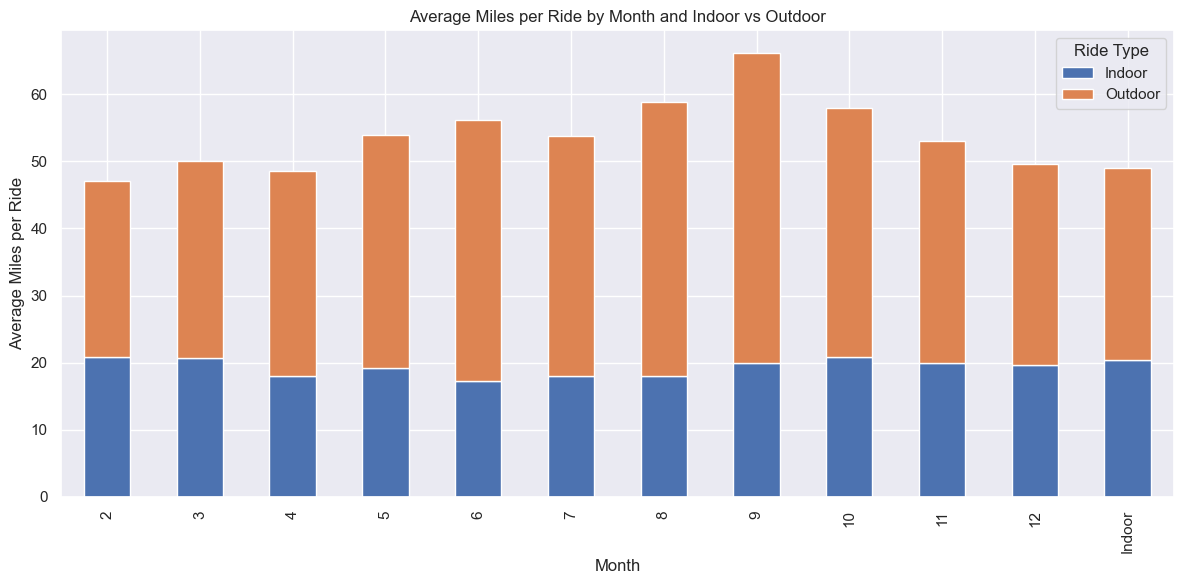

In [71]:
# Visualize monthly miles by indoor vs outdoor
monthly_detail['avg_miles'].unstack(level=1).plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Average Miles per Ride by Month and Indoor vs Outdoor')
plt.xlabel('Month')
plt.ylabel('Average Miles per Ride')
plt.legend(title='Ride Type')
plt.tight_layout()
plt.show()  

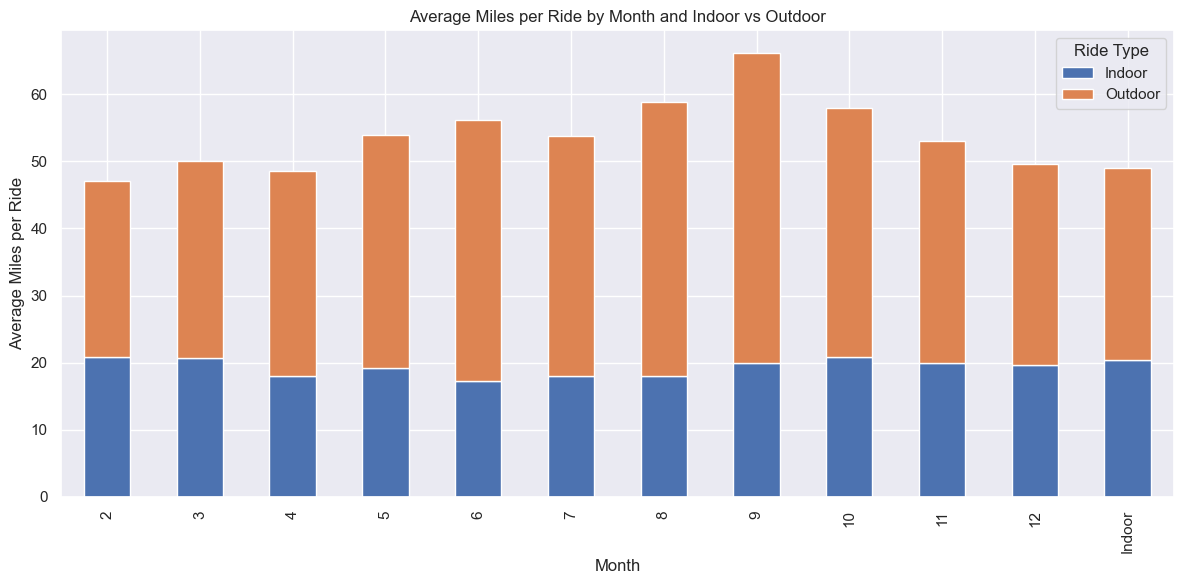

In [ ]:
# Visualize monthly miles by indoor vs outdoor
monthly_detail['avg_miles'].unstack(level=1).plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Average Miles per Ride by Month and Indoor vs Outdoor')
plt.xlabel('Month')
plt.ylabel('Average Miles per Ride')
plt.legend(title='Ride Type')
plt.tight_layout()
plt.show()  

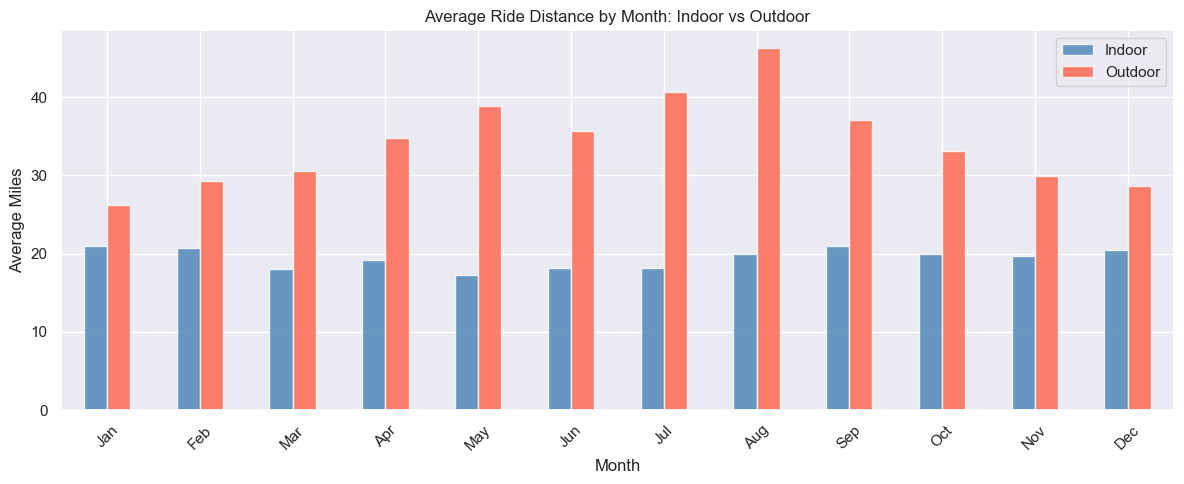

In [72]:
fig, ax = plt.subplots(figsize=(12, 5))

monthly_detail['avg_miles'].unstack().plot(
    kind='bar',
    ax=ax,
    color=['steelblue', 'tomato'],
    alpha=0.8
)

ax.set_title('Average Ride Distance by Month: Indoor vs Outdoor')
ax.set_xlabel('Month')
ax.set_ylabel('Average Miles')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax.legend(['Indoor', 'Outdoor'])
plt.tight_layout()
plt.show()

### Observations
- The cycling year naturally divides into thirds:
  - Jan–Apr: gradual ramp-up as weather improves
  - May–Aug: peak season with highest volume and longest rides, August leading
  - Sep–Dec: gradual wind-down with increasing indoor riding
- Indoor rides maintain consistent ~20-mile average year-round
- Outdoor rides peak at 40+ miles average in summer months

## Section 3: Training Load & Fitness Modeling
Using the Performance Manager model (CTL/ATL/TSB) to reconstruct 
fitness, fatigue, and form across 12 years of power data.

- **TSS** (Training Stress Score): Load from a single ride
- **CTL** (Chronic Training Load): 42-day fitness estimate  
- **ATL** (Acute Training Load): 7-day fatigue estimate
- **TSB** (Training Stress Balance): Form = CTL - ATL
"""

In [73]:
# Calculate TSS for every ride setting current FTP to 213
FTP = 213

rides['IF'] = rides['wap'] / FTP
rides['TSS'] = (rides['IF'] ** 2) * rides['moving_time_hrs'] * 100

# Preview
print(rides[rides['TSS'].notna()][['date', 'Activity Name', 'distance_miles', 'wap', 'IF', 'TSS']].tail(10).round(2))

                    date           Activity Name  distance_miles    wap    IF  \
1334 2026-04-11 10:28:29            Morning Ride           33.28  184.0  0.86   
1335 2026-04-12 12:28:57            Morning Ride           50.04  156.0  0.73   
1336 2026-04-14 21:17:31              Totten Key           15.67  112.0  0.53   
1337 2026-04-18 12:07:38      Flèche Buffoon ‘26           59.23  174.0  0.82   
1338 2026-04-22 09:17:21         Grassy Ridge +2           20.23  170.0  0.80   
1339 2026-04-23 09:06:44                 Fayette           25.95  137.0  0.64   
1340 2026-04-27 19:39:23          Afternoon Ride           25.52  183.0  0.86   
1341 2026-04-28 17:33:12          Afternoon Ride           47.13  179.0  0.84   
1342 2026-04-29 18:11:12  Afternoon Ride 💧☔️🌧️🌦️           24.13  146.0  0.69   
1343 2026-04-30 13:23:16            Morning Ride            6.67  100.0  0.47   

         TSS  
1334  140.64  
1335  159.40  
1336   20.74  
1337  288.62  
1338   63.70  
1339   51.71  
134

In [76]:
# Normalize date to remove time component
rides['date_only'] = rides['date'].dt.normalize()

# Sum TSS per day
daily_tss = rides.groupby('date_only')['TSS'].sum()

# Reindex to fill every calendar day with 0 for rest days
date_range = pd.date_range(start=daily_tss.index.min(), end=daily_tss.index.max(), freq='D')
daily_tss = daily_tss.reindex(date_range, fill_value=0)

print(f"Daily TSS series: {len(daily_tss)} days")
print(f"Days with riding: {(daily_tss > 0).sum()}")
print(f"Average TSS on riding days: {daily_tss[daily_tss > 0].mean().round(1)}")
print(daily_tss.tail(10).round(1))


Daily TSS series: 4191 days
Days with riding: 1136
Average TSS on riding days: 105.4
2026-04-21      0.0
2026-04-22     63.7
2026-04-23     51.7
2026-04-24      0.0
2026-04-25      0.0
2026-04-26      0.0
2026-04-27    108.4
2026-04-28    213.4
2026-04-29     85.1
2026-04-30     16.5
Freq: D, Name: TSS, dtype: float64
